# 4. Modélisation supervisée et semi-supervisée avec un CNN entraîné de zéro

Objectif : comparer une baseline supervisée avec deux approches semi-supervisées, en utilisant un CNN initialisé aléatoirement et entraîné directement sur les images.

La pseudo-labellisation semi-supervisée repose sur la pureté des clusters KMeans et DBSCAN calculés dans l'espace des embeddings. Le CNN final, lui, est entraîné de zéro : aucun modèle préentraîné n'est fine-tuné pour la classification finale.


## Principe expérimental

Trois approches sont comparées :

1. **Supervisé fort uniquement** : le CNN est entraîné de zéro uniquement sur les images fortement labellisées du train.
2. **Semi-supervisé KMeans** : les images non labellisées situées dans des clusters KMeans suffisamment purs reçoivent un pseudo-label, puis le CNN est entraîné de zéro sur labels forts + pseudo-labels.
3. **Semi-supervisé DBSCAN** : même protocole, mais avec des clusters DBSCAN.

Le seuil `0.95` correspond à une pureté de cluster : un cluster est retenu si au moins 95 % des images fortement labellisées qu'il contient appartiennent à la même classe.


In [91]:
# Imports
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    classification_report,
)

RANDOM_STATE = 42
OUTPUT_DIR = Path("data/processed")
FEATURES_PATH = OUTPUT_DIR / "resnet18_features.csv"
TEST_SIZE = 0.50
CLUSTER_PURITY_THRESHOLD = 0.95
RECALL_BETA = 2.0

IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0

SUPERVISED_EPOCHS = 20
SEMI_SUPERVISED_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

LABEL_TO_ID = {"normal": 0, "cancer": 1}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()


Device: cpu


In [92]:
# Chargement des embeddings pour la pseudo-labellisation par clustering
features_df = pd.read_csv(FEATURES_PATH)
feature_columns = [col for col in features_df.columns if col.startswith("feature_")]
features_df["path"] = features_df["path"].astype(str)

strong_df = features_df[features_df["label"].isin(["normal", "cancer"])].copy()
unknown_df = features_df[features_df["label"].eq("unknown")].copy()

print("Images fortement labellisées:", strong_df.shape)
print(strong_df["label"].value_counts())
print("Images non labellisées:", unknown_df.shape)
print("Nombre de features d'embedding:", len(feature_columns))


Images fortement labellisées: (100, 515)
label
cancer    50
normal    50
Name: count, dtype: int64
Images non labellisées: (1406, 515)
Nombre de features d'embedding: 512


## Préparation des images

Le CNN apprend directement depuis les images. Les embeddings servent uniquement à identifier les clusters fiables pour pseudo-labelliser les images non labellisées.


In [93]:
# Transformations d’images pour un CNN entraîné de zéro
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


class BrainMRIDataset(Dataset):
    def __init__(self, df, label_col="training_label", transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.label_col = label_col
        self.transform = transform or eval_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        image = self.transform(image)
        label = LABEL_TO_ID[row[self.label_col]]
        return image, torch.tensor(label, dtype=torch.long)


def make_loader(df, label_col="training_label", shuffle=False, transform=None):
    dataset = BrainMRIDataset(df, label_col=label_col, transform=transform)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


## Architecture CNN

Le modèle est compact pour limiter le surapprentissage sur un petit jeu fortement labellisé. Il est initialisé de zéro à chaque expérience.


In [94]:
# Petit CNN initialisé de zéro
class SmallBrainCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def make_cnn():
    set_seed()
    return SmallBrainCNN(num_classes=len(LABEL_TO_ID)).to(device)


def train_model(model, train_df, epochs, phase_name, label_col="training_label", lr=LEARNING_RATE):
    loader = make_loader(train_df, label_col=label_col, shuffle=True, transform=train_transform)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_seen = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_seen += batch_size

        history.append({
            "phase": phase_name,
            "epoch": epoch,
            "loss": total_loss / max(total_seen, 1),
            "accuracy": total_correct / max(total_seen, 1),
        })

    return pd.DataFrame(history)


def predict_labels(model, df, label_col="label"):
    loader = make_loader(df, label_col=label_col, shuffle=False, transform=eval_transform)
    model.eval()
    predictions = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            logits = model(images)
            pred_ids = logits.argmax(dim=1).cpu().numpy()
            predictions.extend([ID_TO_LABEL[int(pred_id)] for pred_id in pred_ids])

    return np.array(predictions)


def compute_metrics(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_cancer": f1_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "f2_cancer": fbeta_score(y_true, y_pred, beta=RECALL_BETA, pos_label="cancer", zero_division=0),
        "recall_cancer": recall_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "precision_cancer": precision_score(y_true, y_pred, pos_label="cancer", zero_division=0),
    }


def evaluate_model(model, test_df, model_name):
    y_true = test_df["label"].values
    y_pred = predict_labels(model, test_df, label_col="label")
    metrics = compute_metrics(y_true, y_pred, model_name)
    print(model_name)
    print(classification_report(y_true, y_pred, zero_division=0))
    return metrics, y_pred


## Split final équilibré

Le split est stratifié pour conserver l'équilibre entre `normal` et `cancer`. Les images du test restent invisibles pendant la pseudo-labellisation et pendant l'entraînement.


In [95]:
train_idx, test_idx = train_test_split(
    strong_df.index,
    test_size=TEST_SIZE,
    stratify=strong_df["label"],
    random_state=RANDOM_STATE,
)

train_strong_df = strong_df.loc[train_idx].copy()
test_strong_df = strong_df.loc[test_idx].copy()
train_strong_df["training_label"] = train_strong_df["label"]

print("Train fort:")
print(train_strong_df["label"].value_counts())
print("Test fort:")
print(test_strong_df["label"].value_counts())


Train fort:
label
cancer    25
normal    25
Name: count, dtype: int64
Test fort:
label
normal    25
cancer    25
Name: count, dtype: int64


## Baseline supervisée

La baseline entraîne un CNN de zéro uniquement sur les labels forts du train. Elle sert de référence pour mesurer l'apport des pseudo-labels.


In [96]:
# Baseline supervisée : entraînement de zéro sur les labels forts uniquement
supervised_model = make_cnn()
supervised_history = train_model(
    supervised_model,
    train_strong_df,
    epochs=SUPERVISED_EPOCHS,
    phase_name="strong_supervised",
)
supervised_metrics, supervised_pred = evaluate_model(
    supervised_model,
    test_strong_df,
    "supervised_strong_only_cnn",
)
supervised_metrics


supervised_strong_only_cnn
              precision    recall  f1-score   support

      cancer       0.53      1.00      0.69        25
      normal       1.00      0.12      0.21        25

    accuracy                           0.56        50
   macro avg       0.77      0.56      0.45        50
weighted avg       0.77      0.56      0.45        50



{'model': 'supervised_strong_only_cnn',
 'accuracy': 0.56,
 'precision_macro': 0.7659574468085106,
 'recall_macro': 0.56,
 'f1_macro': 0.45436507936507936,
 'f1_cancer': 0.6944444444444444,
 'f2_cancer': 0.8503401360544217,
 'recall_cancer': 1.0,
 'precision_cancer': 0.5319148936170213}

## Pseudo-labellisation par clusters purs

Pour chaque split, les clusters sont construits sans utiliser les labels du test. Les labels forts du train servent uniquement à estimer la pureté des clusters. Les images non labellisées reçoivent un pseudo-label seulement si leur cluster atteint la pureté minimale de `0.95`.


In [97]:
def assign_clusters(df, feature_columns, method, **config):
    X = df[feature_columns].values

    if method == "kmeans":
        clustering_model = make_pipeline(
            StandardScaler(),
            KMeans(n_clusters=config["k"], random_state=RANDOM_STATE, n_init=10),
        )
        return clustering_model.fit_predict(X)

    if method == "dbscan":
        clustering_model = make_pipeline(
            StandardScaler(),
            DBSCAN(eps=config["eps"], min_samples=config["min_samples"]),
        )
        return clustering_model.fit_predict(X)

    raise ValueError(f"Unknown clustering method: {method}")


def build_selective_pseudo_labels(
    train_strong_df,
    unknown_df,
    feature_columns,
    method,
    purity_threshold=0.95,
    min_labeled_per_cluster=2,
    mode="both",
    **cluster_config,
):
    pseudo_source_df = pd.concat([train_strong_df, unknown_df], axis=0).copy()
    pseudo_source_df["cluster_modeling"] = assign_clusters(
        pseudo_source_df,
        feature_columns,
        method=method,
        **cluster_config,
    )

    if method == "dbscan":
        pseudo_source_df = pseudo_source_df[pseudo_source_df["cluster_modeling"].ne(-1)].copy()

    train_with_clusters = pseudo_source_df[pseudo_source_df["label"].isin(["normal", "cancer"])].copy()
    unknown_with_clusters = pseudo_source_df[pseudo_source_df["label"].eq("unknown")].copy()

    cluster_counts = pd.crosstab(train_with_clusters["cluster_modeling"], train_with_clusters["label"])
    for label in ["cancer", "normal"]:
        if label not in cluster_counts.columns:
            cluster_counts[label] = 0

    cluster_counts = cluster_counts[["cancer", "normal"]]
    cluster_stats = cluster_counts.copy()
    cluster_stats["n_labeled"] = cluster_stats.sum(axis=1)
    cluster_stats["majority_label"] = cluster_counts.idxmax(axis=1)
    cluster_stats["purity"] = cluster_counts.max(axis=1) / cluster_stats["n_labeled"]

    selected_clusters = cluster_stats[
        (cluster_stats["n_labeled"] >= min_labeled_per_cluster)
        & (cluster_stats["purity"] >= purity_threshold)
    ].copy()

    if mode == "cancer_only":
        selected_clusters = selected_clusters[selected_clusters["majority_label"].eq("cancer")]

    cluster_to_label = selected_clusters["majority_label"].to_dict()
    cluster_to_purity = selected_clusters["purity"].to_dict()
    cluster_to_n = selected_clusters["n_labeled"].to_dict()

    unknown_with_clusters["pseudo_label"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_label)
    unknown_with_clusters["cluster_purity"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_purity)
    unknown_with_clusters["cluster_labeled_count"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_n)

    pseudo_labeled_df = unknown_with_clusters.dropna(subset=["pseudo_label"]).copy()
    pseudo_labeled_df["training_label"] = pseudo_labeled_df["pseudo_label"]

    return pseudo_labeled_df, cluster_stats, selected_clusters


In [98]:
KMEANS_CONFIG = {
    "method": "kmeans",
    "k": 10,
    "purity_threshold": CLUSTER_PURITY_THRESHOLD,
    "min_labeled_per_cluster": 2,
    "mode": "both",
}

DBSCAN_CONFIG = {
    "method": "dbscan",
    "eps": 21.5,
    "min_samples": 12,
    "purity_threshold": CLUSTER_PURITY_THRESHOLD,
    "min_labeled_per_cluster": 2,
    "mode": "both",
}

MODEL_CONFIGS = {
    "kmeans_selective": KMEANS_CONFIG,
    "dbscan_selective": DBSCAN_CONFIG,
}


## Entraînement semi-supervisé

Pour chaque méthode de clustering, le CNN est entraîné de zéro sur le jeu enrichi : labels forts du train + pseudo-labels issus des clusters purs.


In [99]:
def fit_semi_supervised_cnn(train_strong_df, unknown_df, config, model_name):
    pseudo_labeled_df, cluster_stats, selected_clusters = build_selective_pseudo_labels(
        train_strong_df,
        unknown_df,
        feature_columns,
        **config,
    )

    print(f"{model_name}: {len(pseudo_labeled_df)} pseudo-labels retenus")
    print(pseudo_labeled_df["pseudo_label"].value_counts())

    semi_train_df = pd.concat([train_strong_df, pseudo_labeled_df], axis=0, ignore_index=True)
    model = make_cnn()
    history = train_model(model, semi_train_df, epochs=SEMI_SUPERVISED_EPOCHS, phase_name=model_name)
    metrics, predictions = evaluate_model(model, test_strong_df, model_name)

    return {
        "model": model,
        "history": history,
        "metrics": metrics,
        "predictions": predictions,
        "semi_train_df": semi_train_df,
        "pseudo_labeled_df": pseudo_labeled_df,
        "cluster_stats": cluster_stats,
        "selected_clusters": selected_clusters,
    }


In [100]:
# Comparaison semi-supervisée sur le split final
semi_results = {}

for model_name, config in MODEL_CONFIGS.items():
    semi_results[model_name] = fit_semi_supervised_cnn(
        train_strong_df,
        unknown_df,
        config,
        f"semi_supervised_{model_name}_cnn",
    )


semi_supervised_kmeans_selective_cnn: 966 pseudo-labels retenus
pseudo_label
cancer    767
normal    199
Name: count, dtype: int64
semi_supervised_kmeans_selective_cnn
              precision    recall  f1-score   support

      cancer       0.92      0.88      0.90        25
      normal       0.88      0.92      0.90        25

    accuracy                           0.90        50
   macro avg       0.90      0.90      0.90        50
weighted avg       0.90      0.90      0.90        50

semi_supervised_dbscan_selective_cnn: 322 pseudo-labels retenus
pseudo_label
cancer    322
Name: count, dtype: int64
semi_supervised_dbscan_selective_cnn
              precision    recall  f1-score   support

      cancer       1.00      0.44      0.61        25
      normal       0.64      1.00      0.78        25

    accuracy                           0.72        50
   macro avg       0.82      0.72      0.70        50
weighted avg       0.82      0.72      0.70        50



In [101]:
# Vérification des fuites : aucune image de test ne doit apparaître dans les jeux d’entraînement
test_paths = set(test_strong_df["path"])
for model_name, result in semi_results.items():
    overlap = test_paths.intersection(set(result["semi_train_df"]["path"]))
    print(model_name, "overlap test/train:", len(overlap))
    assert len(overlap) == 0


kmeans_selective overlap test/train: 0
dbscan_selective overlap test/train: 0


In [102]:
metrics_df = pd.DataFrame([supervised_metrics] + [result["metrics"] for result in semi_results.values()])
metrics_df


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_cancer,f2_cancer,recall_cancer,precision_cancer
0,supervised_strong_only_cnn,0.56,0.765957,0.56,0.454365,0.694444,0.850340,1.00,0.531915
1,semi_supervised_kmeans_selective_cnn,0.90,0.900641,0.90,0.899960,0.897959,0.887097,0.88,0.916667
2,semi_supervised_dbscan_selective_cnn,0.72,0.820513,0.72,0.696181,0.611111,0.495495,0.44,1.000000


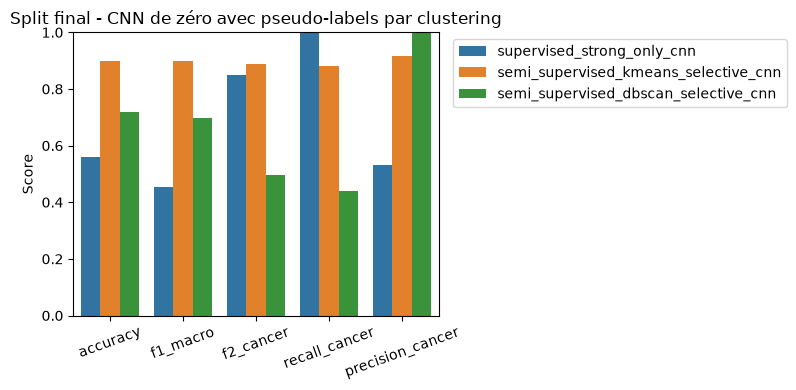

In [103]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_macro", "f2_cancer", "recall_cancer", "precision_cancer"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_df, x="metric", y="score", hue="model", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Split final - CNN de zéro avec pseudo-labels par clustering")
ax.set_xlabel("")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Validation croisée

La validation croisée à cinq plis est la comparaison principale. À chaque pli, les clusters sont caractérisés avec les labels forts du train du pli, puis l'évaluation est faite sur le fold de test jamais vu.


In [104]:
def metric_row(fold, model_name, y_true, y_pred, extra=None):
    row = {
        "fold": fold,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_cancer": f1_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "f2_cancer": fbeta_score(y_true, y_pred, beta=RECALL_BETA, pos_label="cancer", zero_division=0),
        "recall_cancer": recall_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "precision_cancer": precision_score(y_true, y_pred, pos_label="cancer", zero_division=0),
    }
    if extra:
        row.update(extra)
    return row


def supervised_cv_cnn(strong_df, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    y = strong_df["label"].values
    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(strong_df, y), start=1):
        print(f"Fold {fold} - supervised CNN")
        train_fold = strong_df.iloc[train_pos].copy()
        test_fold = strong_df.iloc[test_pos].copy()
        train_fold["training_label"] = train_fold["label"]

        model = make_cnn()
        train_model(model, train_fold, epochs=SUPERVISED_EPOCHS, phase_name="strong_supervised")
        y_pred = predict_labels(model, test_fold, label_col="label")

        results.append(metric_row(
            fold,
            "supervised_strong_only_cnn_cv",
            test_fold["label"].values,
            y_pred,
            {"n_pseudo": 0, "n_pseudo_cancer": 0, "n_pseudo_normal": 0, "n_selected_clusters": 0},
        ))

    return pd.DataFrame(results)


def semi_supervised_cv_cnn(strong_df, unknown_df, config, model_name, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    y = strong_df["label"].values
    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(strong_df, y), start=1):
        print(f"Fold {fold} - {model_name}")
        train_fold = strong_df.iloc[train_pos].copy()
        test_fold = strong_df.iloc[test_pos].copy()
        train_fold["training_label"] = train_fold["label"]

        pseudo_fold, _, selected_clusters_fold = build_selective_pseudo_labels(
            train_fold,
            unknown_df,
            feature_columns,
            **config,
        )
        semi_train_fold = pd.concat([train_fold, pseudo_fold], axis=0, ignore_index=True)
        overlap = set(test_fold["path"]).intersection(set(semi_train_fold["path"]))
        assert len(overlap) == 0

        model = make_cnn()
        train_model(model, semi_train_fold, epochs=SEMI_SUPERVISED_EPOCHS, phase_name=model_name)
        y_pred = predict_labels(model, test_fold, label_col="label")
        pseudo_counts = pseudo_fold["pseudo_label"].value_counts()

        results.append(metric_row(
            fold,
            model_name,
            test_fold["label"].values,
            y_pred,
            {
                "n_pseudo": len(pseudo_fold),
                "n_pseudo_cancer": pseudo_counts.get("cancer", 0),
                "n_pseudo_normal": pseudo_counts.get("normal", 0),
                "n_selected_clusters": len(selected_clusters_fold),
                "purity_threshold": config["purity_threshold"],
                "min_labeled_per_cluster": config["min_labeled_per_cluster"],
                "clustering_method": config["method"],
            },
        ))

    return pd.DataFrame(results)


In [105]:
# La validation croisée peut être longue sur CPU. Réduire les epochs ci-dessus pour un test rapide.
supervised_cv_df = supervised_cv_cnn(strong_df)
semi_cv_dfs = []
for model_name, config in MODEL_CONFIGS.items():
    semi_cv_dfs.append(
        semi_supervised_cv_cnn(
            strong_df,
            unknown_df,
            config,
            f"semi_supervised_{model_name}_cnn_cv",
        )
    )

cv_results_df = pd.concat([supervised_cv_df] + semi_cv_dfs, axis=0, ignore_index=True)
cv_results_df


Fold 1 - supervised CNN
Fold 2 - supervised CNN
Fold 3 - supervised CNN
Fold 4 - supervised CNN
Fold 5 - supervised CNN
Fold 1 - semi_supervised_kmeans_selective_cnn_cv
Fold 2 - semi_supervised_kmeans_selective_cnn_cv
Fold 3 - semi_supervised_kmeans_selective_cnn_cv
Fold 4 - semi_supervised_kmeans_selective_cnn_cv
Fold 5 - semi_supervised_kmeans_selective_cnn_cv
Fold 1 - semi_supervised_dbscan_selective_cnn_cv
Fold 2 - semi_supervised_dbscan_selective_cnn_cv
Fold 3 - semi_supervised_dbscan_selective_cnn_cv
Fold 4 - semi_supervised_dbscan_selective_cnn_cv
Fold 5 - semi_supervised_dbscan_selective_cnn_cv


,fold,model,accuracy,f1_macro,f1_cancer,f2_cancer,recall_cancer,precision_cancer,n_pseudo,n_pseudo_cancer,n_pseudo_normal,n_selected_clusters,purity_threshold,min_labeled_per_cluster,clustering_method
0,1,supervised_strong_only_cnn_cv,0.55,0.435737,0.689655,0.847458,1.0,0.526316,0,0,0,0,NaN,NaN,NaN
1,2,supervised_strong_only_cnn_cv,0.75,0.733333,0.800000,0.909091,1.0,0.666667,0,0,0,0,NaN,NaN,NaN
2,3,supervised_strong_only_cnn_cv,0.65,0.601140,0.740741,0.877193,1.0,0.588235,0,0,0,0,NaN,NaN,NaN
3,4,supervised_strong_only_cnn_cv,0.65,0.601140,0.740741,0.877193,1.0,0.588235,0,0,0,0,NaN,NaN,NaN
4,5,supervised_strong_only_cnn_cv,0.75,0.733333,0.800000,0.909091,1.0,0.666667,0,0,0,0,NaN,NaN,NaN
5,1,semi_supervised_kmeans_selective_cnn_cv,0.85,0.846547,0.869565,0.943396,1.0,0.769231,538,447,91,4,0.95,2.0,kmeans
6,2,semi_supervised_kmeans_selective_cnn_cv,0.85,0.846547,0.869565,0.943396,1.0,0.769231,479,479,0,3,0.95,2.0,kmeans
7,3,semi_supervised_kmeans_selective_cnn_cv,0.90,0.898990,0.888889,0.833333,0.8,1.000000,561,447,114,4,0.95,2.0,kmeans
8,4,semi_supervised_kmeans_selective_cnn_cv,0.80,0.791667,0.833333,0.925926,1.0,0.714286,743,619,124,5,0.95,2.0,kmeans
9,5,semi_supervised_kmeans_selective_cnn_cv,0.55,0.435737,0.689655,0.847458,1.0,0.526316,691,499,192,5,0.95,2.0,kmeans


In [106]:
cv_summary = (
    cv_results_df
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_std=("f1_macro", "std"),
        f2_cancer_mean=("f2_cancer", "mean"),
        f2_cancer_std=("f2_cancer", "std"),
        recall_cancer_mean=("recall_cancer", "mean"),
        precision_cancer_mean=("precision_cancer", "mean"),
        n_pseudo_mean=("n_pseudo", "mean"),
    )
    .reset_index()
)
cv_summary


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f2_cancer_mean,f2_cancer_std,recall_cancer_mean,precision_cancer_mean,n_pseudo_mean
0,semi_supervised_dbscan_selective_cnn_cv,0.82,0.103682,0.808284,0.124030,0.883761,0.034021,0.92,0.804141,263.8
1,semi_supervised_kmeans_selective_cnn_cv,0.79,0.138744,0.763898,0.187332,0.898702,0.053934,0.96,0.755813,602.4
2,supervised_strong_only_cnn_cv,0.67,0.083666,0.620937,0.122830,0.884005,0.025919,1.00,0.607224,0.0


## Optimisation du recall

Dans ce projet, le rappel de la classe `cancer` est prioritaire : on veut éviter qu'une méthode semi-supervisée améliore la performance globale tout en détectant moins bien les cas `cancer`.

Le score F-beta avec `beta = 2` donne plus de poids au recall qu'à la précision. Il ne garantit pas à lui seul que le rappel reste au niveau de la baseline ; il sert plutôt à classer les modèles après avoir appliqué une contrainte : `recall_cancer_mean >= recall_cancer_mean` de la baseline supervisée.


In [107]:
# Sélection orientée recall : ne retenir que les modèles qui ne perdent pas en recall cancer
baseline_recall = cv_summary.loc[
    cv_summary["model"].eq("supervised_strong_only_cnn_cv"),
    "recall_cancer_mean",
].iloc[0]

recall_optimized_summary = cv_summary.copy()
recall_optimized_summary["recall_constraint_ok"] = (
    recall_optimized_summary["recall_cancer_mean"] >= baseline_recall
)

recall_optimized_summary = recall_optimized_summary.sort_values(
    by=["recall_constraint_ok", "f2_cancer_mean", "f1_macro_mean"],
    ascending=[False, False, False],
).reset_index(drop=True)

recall_optimized_summary[[
    "model",
    "recall_constraint_ok",
    "recall_cancer_mean",
    "f2_cancer_mean",
    "f1_macro_mean",
    "precision_cancer_mean",
    "n_pseudo_mean",
]]


,model,recall_constraint_ok,recall_cancer_mean,f2_cancer_mean,f1_macro_mean,precision_cancer_mean,n_pseudo_mean
0,supervised_strong_only_cnn_cv,True,1.00,0.884005,0.620937,0.607224,0.0
1,semi_supervised_kmeans_selective_cnn_cv,False,0.96,0.898702,0.763898,0.755813,602.4
2,semi_supervised_dbscan_selective_cnn_cv,False,0.92,0.883761,0.808284,0.804141,263.8


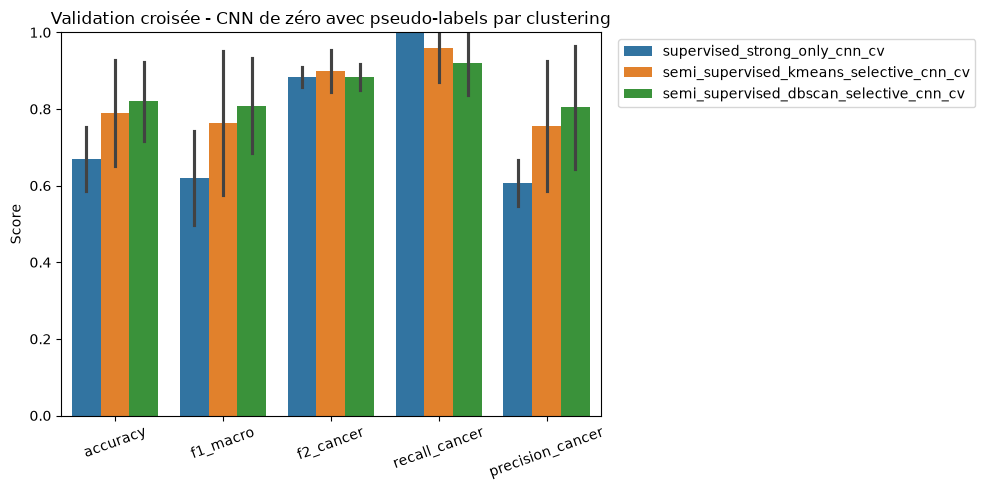

In [108]:
cv_plot_df = cv_results_df.melt(
    id_vars=["fold", "model"],
    value_vars=["accuracy", "f1_macro", "f2_cancer", "recall_cancer", "precision_cancer"],
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=cv_plot_df, x="metric", y="score", hue="model", errorbar="sd", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Validation croisée - CNN de zéro avec pseudo-labels par clustering")
ax.set_xlabel("")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Interprétation attendue

Cette étape mesure si les pseudo-labels issus de clusters purs améliorent un CNN entraîné de zéro. L'interprétation doit distinguer la qualité de la pseudo-labellisation et la performance finale du CNN.

Le split final donne une lecture simple, mais la validation croisée reste la comparaison principale.


In [109]:
# Sauvegarde des sorties du protocole clustering + CNN
metrics_path = OUTPUT_DIR / "modeling_metrics_cluster_cnn_selective.csv"
cv_results_path = OUTPUT_DIR / "modeling_cv_results_cluster_cnn_selective.csv"
cv_summary_path = OUTPUT_DIR / "modeling_cv_summary_cluster_cnn_selective.csv"

metrics_df.to_csv(metrics_path, index=False)
cv_results_df.to_csv(cv_results_path, index=False)
cv_summary.to_csv(cv_summary_path, index=False)

for model_name, result in semi_results.items():
    prefix = MODEL_CONFIGS[model_name]["method"]
    result["pseudo_labeled_df"].to_csv(
        OUTPUT_DIR / f"pseudo_labels_{prefix}_cluster_cnn_selective.csv",
        index=False,
    )
    result["semi_train_df"].to_csv(
        OUTPUT_DIR / f"semi_supervised_training_set_{prefix}_cluster_cnn_selective.csv",
        index=False,
    )
    result["cluster_stats"].to_csv(
        OUTPUT_DIR / f"{prefix}_cluster_purity_cluster_cnn_modeling.csv",
    )
    result["selected_clusters"].to_csv(
        OUTPUT_DIR / f"{prefix}_selected_clusters_cluster_cnn_modeling.csv",
    )

print("Final split metrics:", metrics_path)
print("CV results:", cv_results_path)
print("CV summary:", cv_summary_path)


Final split metrics: data\processed\modeling_metrics_cluster_cnn_selective.csv
CV results: data\processed\modeling_cv_results_cluster_cnn_selective.csv
CV summary: data\processed\modeling_cv_summary_cluster_cnn_selective.csv


## Definition of Done - étape 4

L'étape 4 est terminée si :

- un CNN initialisé de zéro est entraîné sur les labels forts uniquement pour produire la baseline supervisée ;
- les pseudo-labels sont générés à partir des clusters KMeans et DBSCAN calculés sur les embeddings ;
- seuls les clusters dont la pureté est supérieure ou égale à `CLUSTER_PURITY_THRESHOLD` sont retenus ;
- les approches semi-supervisées KMeans et DBSCAN entraînent chacune un CNN de zéro sur labels forts + pseudo-labels ;
- chaque évaluation utilise uniquement des données fortement labellisées jamais vues à l'entraînement ;
- le split final et la validation croisée comparent clairement baseline supervisée, KMeans semi-supervisé et DBSCAN semi-supervisé ;
- les fichiers `modeling_metrics_cluster_cnn_selective.csv`, `modeling_cv_results_cluster_cnn_selective.csv`, `modeling_cv_summary_cluster_cnn_selective.csv` et les fichiers de pseudo-labels sont sauvegardés dans `data/processed`.
